# 00 · EDA Geoespacial — Savia Salud EPS
**Fase 0:** Exploración y calidad de datos geoespaciales  
**BD:** `system_savia` · `10.250.5.36`  
**Ventana de análisis:** Últimos 3 meses  
**Reglas activas:** Solo SELECT · Sin PII · Data/raw/ inmutable · Ley 1581

## Índice
1. Conexión y extracción de datos geoespaciales
2. Calidad de coordenadas — afiliados
3. Calidad de coordenadas — IPS/sedes
4. Distribución de afiliados por municipio
5. Distribución de IPS por municipio y nivel de atención
6. Tasa de glosas por municipio
7. Distancia afiliado → IPS asignada (Haversine)
8. Concentración diagnóstica por zona (CIE-10 top por municipio)
9. Brechas de cobertura: municipios sin IPS nivel 1
10. Conclusiones y decisiones para Fase 1

## 0 · Configuración de entorno

In [1]:
# Instalar dependencias si no están disponibles
# !pip install mysql-connector-python pandas numpy matplotlib seaborn folium geopandas scipy python-dotenv pyarrow

import os
import math
import logging
import warnings
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# Rutas del proyecto
BASE_DIR   = Path("d:/Users/jcardonr/Documents/Savia")
RAW_DIR    = BASE_DIR / "Data" / "raw"
PROC_DIR   = BASE_DIR / "Data" / "processed"
FIG_DIR    = BASE_DIR / "reports" / "figures"

for d in [RAW_DIR, PROC_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TODAY = date.today().strftime("%Y%m%d")
RANDOM_STATE = 42

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

logger.info("Entorno configurado · Fecha: %s", TODAY)

INFO | Entorno configurado · Fecha: 20260420


## 1 · Conexión y extracción de datos geoespaciales

**Regla:** Solo queries SELECT. Los resultados se guardan en `Data/raw/` como Parquet (inmutable).

Configura la contraseña en variable de entorno `SAVIA_DB_PASSWORD` o en un archivo `.env` local (no commitear).

In [2]:
from dotenv import load_dotenv
import mysql.connector

# Cargar variables desde .env ANTES de leer os.environ
load_dotenv("d:/Users/jcardonr/Documents/Savia/.env", override=True)

DB_CONFIG = {
    "host":            os.environ.get("SAVIA_DB_HOST",     "10.250.5.36"),
    "database":        os.environ.get("SAVIA_DB_NAME",     "system_savia"),
    "user":            os.environ.get("SAVIA_DB_USER",     "root"),
    "password":        os.environ.get("SAVIA_DB_PASSWORD", ""),
    "connect_timeout": 30,
}

# Verificar que se cargaron las credenciales (sin mostrar contraseña)
logger.info("BD config → host=%s · db=%s · user=%s · password=%s",
            DB_CONFIG["host"], DB_CONFIG["database"], DB_CONFIG["user"],
            "***" if DB_CONFIG["password"] else "⚠️ VACÍA — revisa .env")

def get_connection():
    """Retorna conexión MySQL de solo lectura a system_savia."""
    return mysql.connector.connect(**DB_CONFIG)

def run_query(sql: str, label: str = "") -> pd.DataFrame:
    """Ejecuta un SELECT y retorna DataFrame. Nunca ejecuta DML.

    Args:
        sql: Query SELECT a ejecutar.
        label: Etiqueta para logging.

    Returns:
        DataFrame con resultados.
    """
    assert sql.strip().upper().startswith("SELECT"), "Solo se permiten queries SELECT"
    logger.info("Ejecutando query: %s", label)
    with get_connection() as conn:
        df = pd.read_sql(sql, conn)
    logger.info("  → %d filas · %d cols", len(df), len(df.columns))
    return df

logger.info("Funciones de conexión listas")

INFO | BD config → host=10.250.5.36 · db=system_savia · user=jcardonr · password=***
INFO | Funciones de conexión listas


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# EXTRACCIÓN 1: Dataset geoespacial principal (facturas + geo afiliado + geo IPS)
# Últimos 3 meses · Sin PII
# ─────────────────────────────────────────────────────────────────────────────
SQL_GEO_PRINCIPAL = """
SELECT
    f.id                                        AS factura_id,
    f.fecha_radicacion,
    f.nit                                       AS nit_prestador,
    -- Afiliado (solo ID interno, sin PII)
    aa.id                                       AS afiliado_id,
    aa.mae_zona_valor                           AS zona_afiliado,
    aa.nivel_sisben,
    aa.mae_regimen_valor                        AS regimen,
    aa.mae_grupo_poblacional_valor              AS grupo_poblacional,
    aa.mae_genero_valor                         AS genero,
    TIMESTAMPDIFF(YEAR, aa.fecha_nacimiento, CURDATE()) AS edad,
    aa.discapacidad,
    -- Coordenadas afiliado (preferir latitud_nuevo si existe)
    COALESCE(aac.latitud_nuevo,  aac.latitud)  AS lat_afiliado_raw,
    COALESCE(aac.longitud_nuevo, aac.longitud) AS lng_afiliado_raw,
    -- Municipio de residencia
    gn_res.nombre                              AS municipio_residencia,
    gn_res.mae_region_valor                    AS region_residencia,
    gn_res.gps_latitud                         AS lat_municipio_res,
    gn_res.gps_longitud                        AS lng_municipio_res,
    gn_res.cobertura                           AS municipio_con_cobertura,
    -- IPS asignada (primaria)
    cps.id                                     AS sede_id,
    cps.nombre                                 AS nombre_sede,
    cps.nivel_atencion                         AS nivel_atencion_ips,
    cps.mae_clase_prestador_valor              AS clase_prestador,
    cps.capitacion,
    cps.direccion_georef_latitud               AS lat_ips,
    cps.direccion_georef_longitud              AS lng_ips,
    gn_ips.nombre                             AS municipio_ips,
    gn_ips.mae_region_valor                   AS region_ips,
    -- Diagnóstico principal (CIE-10)
    cd.codigo_dx,
    -- Target (3 clases)
    CASE
        WHEN cad.cm_facturas_id IS NOT NULL THEN 2
        WHEN cag.cm_detalles_id IS NOT NULL THEN 1
        ELSE 0
    END AS target
FROM cm_facturas f
INNER JOIN cm_detalles cd      ON cd.cm_facturas_id = f.id
INNER JOIN aseg_afiliados aa   ON aa.id = cd.aseg_afiliados_id
LEFT  JOIN aseg_afiliado_coordenadas aac ON aac.id_afiliado = aa.id
LEFT  JOIN gn_ubicaciones gn_res ON gn_res.id = aa.residencia_ubicacion_id
LEFT  JOIN cnt_prestador_sedes cps ON cps.id = aa.primaria_cnt_prestador_sedes_id
LEFT  JOIN gn_ubicaciones gn_ips ON gn_ips.id = cps.ubicacion_id
LEFT  JOIN cm_auditoria_motivos_glosas cag ON cag.cm_detalles_id = cd.id
LEFT  JOIN cm_auditoria_devoluciones cad   ON cad.cm_facturas_id = f.id
WHERE f.fecha_radicacion >= DATE_SUB(NOW(), INTERVAL 3 MONTH)
"""

df_raw = run_query(SQL_GEO_PRINCIPAL, label="geo_principal_3m")

# Guardar en raw/ (inmutable desde aquí)
raw_path = RAW_DIR / f"{TODAY}_geo_afiliados_3m.parquet"
df_raw.to_parquet(raw_path, index=False)
logger.info("Guardado en: %s", raw_path)

df_raw.head(3)

INFO | Ejecutando query: geo_principal_3m
INFO |   → 11617161 filas · 29 cols
INFO | Guardado en: d:\Users\jcardonr\Documents\Savia\Data\raw\20260420_geo_afiliados_3m.parquet


,factura_id,fecha_radicacion,nit_prestador,afiliado_id,zona_afiliado,nivel_sisben,regimen,grupo_poblacional,genero,edad,...,nombre_sede,nivel_atencion_ips,clase_prestador,capitacion,lat_ips,lng_ips,municipio_ips,region_ips,codigo_dx,target
0,23877080,2026-01-20 11:33:06,900022519,2406417,Urbana - Cabecera Municipal,1,SUBSIDIADO,Población sisbenizada,Masculino,14,...,ESE HOSPITAL SANTA MARIA SANTA BARBARA,1,None,1,5.870583,-75.564051,SANTA BARBARA,SUROESTE,None,2
1,23877080,2026-01-20 11:33:06,900022519,2406417,Urbana - Cabecera Municipal,1,SUBSIDIADO,Población sisbenizada,Masculino,14,...,ESE HOSPITAL SANTA MARIA SANTA BARBARA,1,None,1,5.870583,-75.564051,SANTA BARBARA,SUROESTE,None,2
2,23877080,2026-01-20 11:33:06,900022519,2406417,Urbana - Cabecera Municipal,1,SUBSIDIADO,Población sisbenizada,Masculino,14,...,ESE HOSPITAL SANTA MARIA SANTA BARBARA,1,None,1,5.870583,-75.564051,SANTA BARBARA,SUROESTE,None,2


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# EXTRACCIÓN 2: Catálogo completo de municipios (gn_ubicaciones)
# ─────────────────────────────────────────────────────────────────────────────
SQL_UBICACIONES = """
SELECT
    id,
    gn_ubicaciones_id   AS parent_id,
    nombre,
    tipo,
    cobertura,
    mae_region_valor    AS region,
    gps_georreferenciada,
    gps_latitud,
    gps_longitud
FROM gn_ubicaciones
"""

df_ubicaciones = run_query(SQL_UBICACIONES, label="gn_ubicaciones")
ub_path = RAW_DIR / f"{TODAY}_gn_ubicaciones.parquet"
df_ubicaciones.to_parquet(ub_path, index=False)
logger.info("Guardado en: %s", ub_path)

df_ubicaciones.head(3)

INFO | Ejecutando query: gn_ubicaciones
INFO |   → 1398 filas · 9 cols
INFO | Guardado en: d:\Users\jcardonr\Documents\Savia\Data\raw\20260420_gn_ubicaciones.parquet


,id,parent_id,nombre,tipo,cobertura,region,gps_georreferenciada,gps_latitud,gps_longitud
0,1,NaN,COLOMBIA,1,0,NaN,0,NaN,NaN
1,2,1.0,ANTIOQUIA,2,0,NaN,0,NaN,NaN
2,3,2.0,MEDELLÍN,3,1,MEDELLIN,1,6.2442,-75.5812


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# EXTRACCIÓN 3: Catálogo completo de sedes IPS
# ─────────────────────────────────────────────────────────────────────────────
SQL_SEDES = """
SELECT
    cps.id,
    cps.cnt_prestadores_id,
    cps.nombre                      AS nombre_sede,
    cps.nivel_atencion,
    cps.mae_clase_prestador_valor   AS clase_prestador,
    cps.estado_sede,
    cps.capitacion,
    cps.zona_precedencia,
    cps.direccion_georreferenciada,
    cps.direccion_georef_latitud    AS lat_ips,
    cps.direccion_georef_longitud   AS lng_ips,
    gn.nombre                      AS municipio,
    gn.mae_region_valor             AS region,
    gn.cobertura                   AS municipio_con_cobertura,
    cp.razon_social,
    cp.nivel_atencion               AS nivel_prestador
FROM cnt_prestador_sedes cps
LEFT JOIN gn_ubicaciones gn ON gn.id = cps.ubicacion_id
LEFT JOIN cnt_prestadores cp ON cp.id = cps.cnt_prestadores_id
WHERE cps.estado_sede = 1
"""

df_sedes = run_query(SQL_SEDES, label="cnt_prestador_sedes")
sedes_path = RAW_DIR / f"{TODAY}_cnt_prestador_sedes.parquet"
df_sedes.to_parquet(sedes_path, index=False)
logger.info("Guardado en: %s", sedes_path)

df_sedes.head(3)

INFO | Ejecutando query: cnt_prestador_sedes
INFO |   → 56555 filas · 16 cols
INFO | Guardado en: d:\Users\jcardonr\Documents\Savia\Data\raw\20260420_cnt_prestador_sedes.parquet


,id,cnt_prestadores_id,nombre_sede,nivel_atencion,clase_prestador,estado_sede,capitacion,zona_precedencia,direccion_georreferenciada,lat_ips,lng_ips,municipio,region,municipio_con_cobertura,razon_social,nivel_prestador
0,1,8,SEDE SIN ESPECIFICAR,4.0,None,1,0.0,U,1,6.300316,-75.570657,MEDELLÍN,MEDELLIN,1.0,IPS SIN ESPECIFICAR,4
1,19,106,CALIXTO RAFAEL ALBERTO HERRERA GOMEZ,1.0,None,1,0.0,U,1,6.214985,-75.570381,MEDELLÍN,MEDELLIN,1.0,CALIXTO RAFAEL ALBERTO HERRERA GOMEZ,2
2,23,41,DARIO ALBERTO SIERRA MORENO,1.0,None,1,0.0,U,1,6.249947,-75.567269,MEDELLÍN,MEDELLIN,1.0,DARIO ALBERTO SIERRA MORENO,2


## 2 · Calidad de coordenadas — Afiliados

Preguntas clave:
- ¿Qué % de afiliados tienen coordenadas GPS válidas en `aseg_afiliado_coordenadas`?
- ¿Las coordenadas están en el rango de Colombia? (lat: 4–12, lng: -77 a -66)
- ¿Cuántos tienen centroide de municipio disponible como fallback?

In [6]:
# Convertir coordenadas afiliado a numeric (están como varchar en BD)
df = df_raw.copy()
df["lat_afiliado"] = pd.to_numeric(df["lat_afiliado_raw"], errors="coerce")
df["lng_afiliado"] = pd.to_numeric(df["lng_afiliado_raw"], errors="coerce")

# Rango válido para Colombia
lat_min, lat_max = -4.5, 14.0
lng_min, lng_max = -82.0, -66.0

df["lat_afiliado_valida"] = df["lat_afiliado"].between(lat_min, lat_max)
df["lng_afiliado_valida"] = df["lng_afiliado"].between(lng_min, lng_max)
df["coords_afiliado_validas"] = df["lat_afiliado_valida"] & df["lng_afiliado_valida"]

# Fallback: centroide del municipio de residencia
df["lat_municipio_valida"] = df["lat_municipio_res"].notna() & df["lat_municipio_res"].between(lat_min, lat_max)
df["tiene_geo"] = df["coords_afiliado_validas"] | df["lat_municipio_valida"]

total = len(df)
n_coords_gps    = df["coords_afiliado_validas"].sum()
n_solo_municipio = (~df["coords_afiliado_validas"] & df["lat_municipio_valida"]).sum()
n_sin_geo       = (~df["tiene_geo"]).sum()

print(f"Total facturas (3m):             {total:>10,}")
print(f"Con GPS propio válido:           {n_coords_gps:>10,}  ({n_coords_gps/total:.1%})")
print(f"Solo centroide municipio:        {n_solo_municipio:>10,}  ({n_solo_municipio/total:.1%})")
print(f"Sin ninguna georreferenciación:  {n_sin_geo:>10,}  ({n_sin_geo/total:.1%})")

Total facturas (3m):             11,617,161
Con GPS propio válido:              256,785  (2.2%)
Solo centroide municipio:        11,359,836  (97.8%)
Sin ninguna georreferenciación:         540  (0.0%)


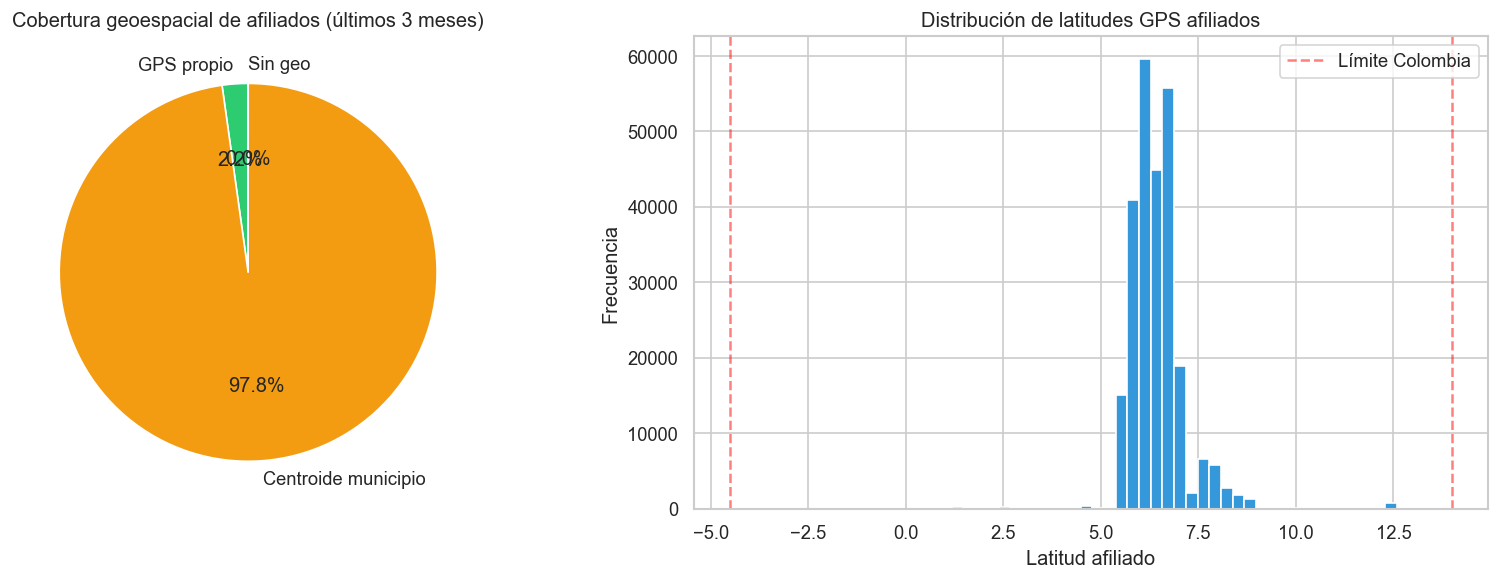

In [7]:
# Visualización de cobertura geoespacial de afiliados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Distribución de fuentes de geo
labels = ["GPS propio", "Centroide municipio", "Sin geo"]
sizes  = [n_coords_gps, n_solo_municipio, n_sin_geo]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
axes[0].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Cobertura geoespacial de afiliados (últimos 3 meses)")

# Gráfica 2: Distribución de latitudes (detectar outliers)
lats_validas = df.loc[df["lat_afiliado_valida"], "lat_afiliado"]
axes[1].hist(lats_validas, bins=50, color="#3498db", edgecolor="white")
axes[1].set_xlabel("Latitud afiliado")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de latitudes GPS afiliados")
axes[1].axvline(lat_min, color="red", linestyle="--", alpha=0.5, label="Límite Colombia")
axes[1].axvline(lat_max, color="red", linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "00_calidad_coords_afiliados.png", bbox_inches="tight")
plt.show()

## 3 · Calidad de coordenadas — IPS / Sedes

In [8]:
df_s = df_sedes.copy()
df_s["lat_ips_valida"] = pd.to_numeric(df_s["lat_ips"], errors="coerce").between(lat_min, lat_max)
df_s["lng_ips_valida"] = pd.to_numeric(df_s["lng_ips"], errors="coerce").between(lng_min, lng_max)
df_s["coords_ips_validas"] = df_s["lat_ips_valida"] & df_s["lng_ips_valida"]

total_sedes = len(df_s)
n_geo_ips   = df_s["coords_ips_validas"].sum()

print(f"Total sedes activas:            {total_sedes:>8,}")
print(f"Con GPS válido:                 {n_geo_ips:>8,}  ({n_geo_ips/total_sedes:.1%})")
print(f"Sin GPS:                        {total_sedes - n_geo_ips:>8,}  ({(total_sedes - n_geo_ips)/total_sedes:.1%})")
print()
print("Por nivel de atención:")
print(df_s.groupby("nivel_atencion")["coords_ips_validas"].agg(["sum", "count"])
      .assign(pct=lambda x: (x["sum"] / x["count"]).map("{:.1%}".format))
      .rename(columns={"sum": "con_GPS", "count": "total"}))

Total sedes activas:              56,555
Con GPS válido:                    3,478  (6.1%)
Sin GPS:                          53,077  (93.9%)

Por nivel de atención:
                con_GPS  total    pct
nivel_atencion                       
1.0                3198  55684   5.7%
2.0                 209    683  30.6%
3.0                  59    154  38.3%
4.0                  12     33  36.4%


## 4 · Distribución de afiliados por municipio

In [9]:
afiliados_por_municipio = (
    df.groupby("municipio_residencia", dropna=False)
    .agg(
        n_facturas=("factura_id", "count"),
        n_afiliados=("afiliado_id", "nunique"),
    )
    .sort_values("n_facturas", ascending=False)
    .reset_index()
)

print(f"Municipios únicos con facturas: {afiliados_por_municipio['municipio_residencia'].nunique()}")
print("\nTop 20 municipios por volumen de facturas:")
print(afiliados_por_municipio.head(20).to_string(index=False))

Municipios únicos con facturas: 126

Top 20 municipios por volumen de facturas:
municipio_residencia  n_facturas  n_afiliados
            MEDELLÍN     3295701       154391
               BELLO      720917        32800
              ITAGUI      425963        17140
            APARTADO      244468        12157
              CAREPA      208503        12097
            ENVIGADO      203055         7322
            RIONEGRO      188700         8409
            CAUCASIA      187421         8852
               TURBO      165627        10014
       PUERTO BERRIO      151074         6619
              CALDAS      147217         6370
              SONSON      142512         9082
           MARINILLA      138967         7479
    SAN PEDRO DE URA      129980         9962
          COPACABANA      129881         6038
             BARBOSA      129876         7040
               ANDES      129388         8405
           CONCORDIA      110523         6157
    SANTA ROSA DE OS      108082         5793


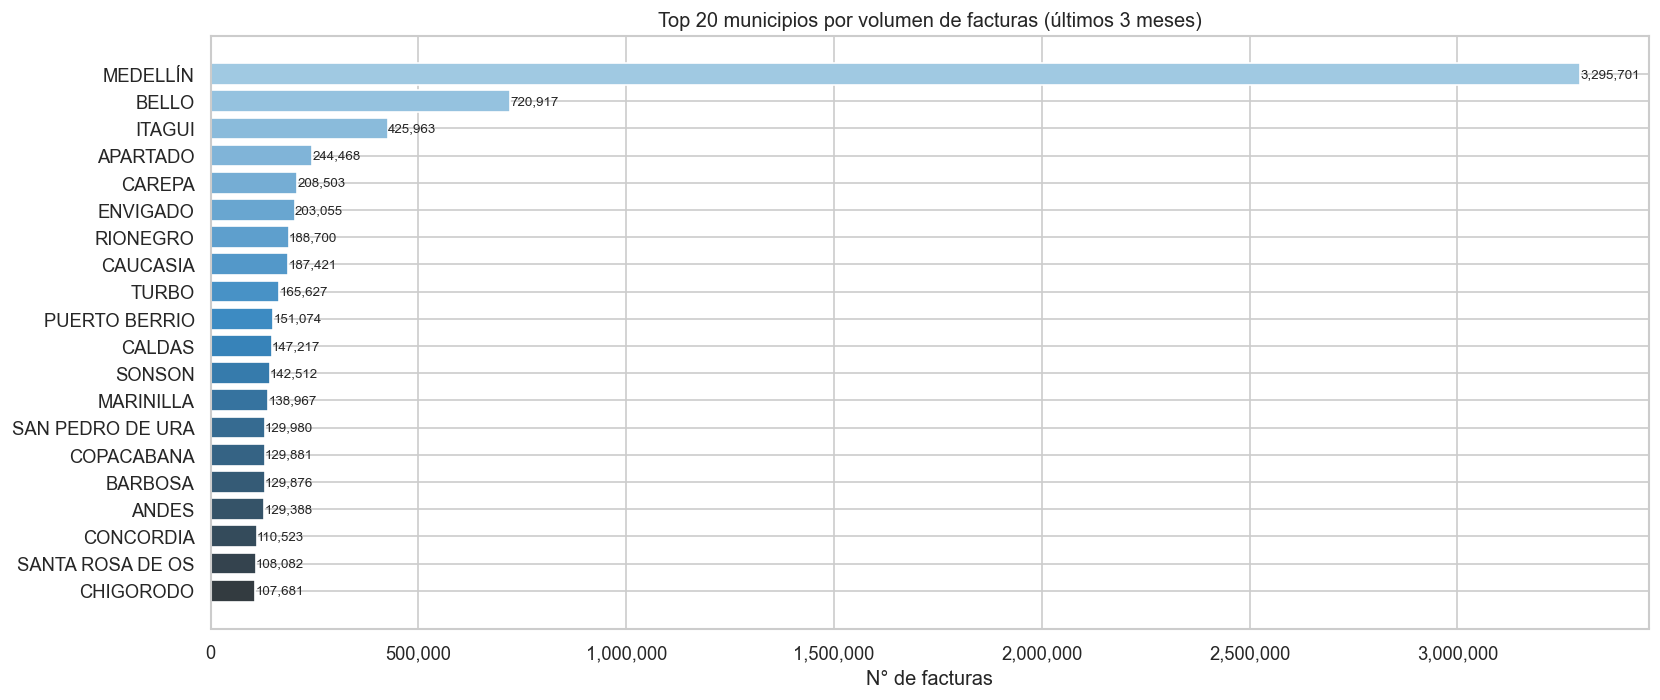

In [10]:
top_n = 20
top_municipios = afiliados_por_municipio.head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    top_municipios["municipio_residencia"].fillna("SIN MUNICIPIO"),
    top_municipios["n_facturas"],
    color=sns.color_palette("Blues_d", top_n)
)
ax.invert_yaxis()
ax.set_xlabel("N° de facturas")
ax.set_title(f"Top {top_n} municipios por volumen de facturas (últimos 3 meses)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "00_afiliados_por_municipio.png", bbox_inches="tight")
plt.show()

## 5 · Distribución de IPS por municipio y nivel de atención

In [11]:
ips_por_municipio = (
    df_sedes.groupby(["municipio", "nivel_atencion"], dropna=False)
    .size()
    .reset_index(name="n_sedes")
    .pivot_table(index="municipio", columns="nivel_atencion", values="n_sedes", fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
    .reset_index()
)

print(f"Municipios con al menos 1 IPS activa: {len(ips_por_municipio)}")
print("\nTop 15 municipios por número de sedes IPS activas:")
print(ips_por_municipio.head(15).to_string(index=False))

Municipios con al menos 1 IPS activa: 1025

Top 15 municipios por número de sedes IPS activas:
    municipio     1.0   2.0  3.0  4.0   total
       BOGOTA 11685.0   0.0  2.0  0.0 11687.0
     MEDELLÍN  6314.0 169.0 31.0 17.0  6531.0
         CALI  3950.0  12.0  3.0  1.0  3966.0
  BOGOTA D.C.  1935.0  42.0 66.0  9.0  2052.0
 BARRANQUILLA  1852.0  20.0  3.0  0.0  1875.0
    CARTAGENA  1350.0   8.0  4.0  0.0  1362.0
  BUCARAMANGA  1150.0   9.0  3.0  1.0  1163.0
      PEREIRA  1120.0   7.0  0.0  0.0  1127.0
       CUCUTA  1028.0  10.0  3.0  0.0  1041.0
    MANIZALES   898.0   3.0  0.0  0.0   901.0
       IBAGUE   859.0  15.0  0.0  0.0   874.0
        PASTO   811.0   4.0  0.0  0.0   815.0
VILLAVICENCIO   646.0  10.0  0.0  0.0   656.0
      ARMENIA   646.0   6.0  1.0  0.0   653.0
     MONTERIA   614.0  15.0  3.0  0.0   632.0


In [12]:
# Municipios con afiliados pero SIN IPS de nivel 1 (brecha de cobertura)
municipios_con_afiliados = set(df["municipio_residencia"].dropna().unique())
municipios_con_nivel1 = set(
    df_sedes.loc[df_sedes["nivel_atencion"] == 1, "municipio"].dropna().unique()
)

brechas = municipios_con_afiliados - municipios_con_nivel1

print(f"Municipios con afiliados:              {len(municipios_con_afiliados)}")
print(f"Municipios con IPS nivel 1:            {len(municipios_con_nivel1)}")
print(f"Municipios SIN IPS nivel 1 (brecha):   {len(brechas)}")

# Volumen de facturas en municipios con brecha
facturas_en_brecha = df[df["municipio_residencia"].isin(brechas)]
print(f"Facturas en municipios con brecha:     {len(facturas_en_brecha):,} ({len(facturas_en_brecha)/len(df):.1%})")

Municipios con afiliados:              126
Municipios con IPS nivel 1:            1012
Municipios SIN IPS nivel 1 (brecha):   0
Facturas en municipios con brecha:     0 (0.0%)


## 6 · Tasa de glosas por municipio

Métrica clave para el modelo predictivo: ¿existen municipios con tasas de glosa significativamente distintas al promedio?

In [13]:
glosas_municipio = (
    df.groupby("municipio_residencia", dropna=False)
    .agg(
        n_facturas=("factura_id", "count"),
        n_glosadas=("target", lambda x: (x == 1).sum()),
        n_devueltas=("target", lambda x: (x == 2).sum()),
        n_auditadas=("target", lambda x: (x == 0).sum()),
    )
    .assign(
        tasa_glosa=lambda x: x["n_glosadas"] / x["n_facturas"],
        tasa_devuelta=lambda x: x["n_devueltas"] / x["n_facturas"],
    )
    .sort_values("n_facturas", ascending=False)
    .reset_index()
)

# Tasa global de referencia
tasa_global_glosa = (df["target"] == 1).mean()
tasa_global_dev   = (df["target"] == 2).mean()

print(f"Tasa global de glosa:    {tasa_global_glosa:.2%}")
print(f"Tasa global de devuelta: {tasa_global_dev:.2%}")
print()
print("Top 20 municipios por volumen (con tasas de glosa):")
print(
    glosas_municipio.head(20)[["municipio_residencia", "n_facturas", "tasa_glosa", "tasa_devuelta"]]
    .assign(
        tasa_glosa=lambda x: x["tasa_glosa"].map("{:.1%}".format),
        tasa_devuelta=lambda x: x["tasa_devuelta"].map("{:.1%}".format),
    )
    .to_string(index=False)
)

Tasa global de glosa:    7.57%
Tasa global de devuelta: 3.35%

Top 20 municipios por volumen (con tasas de glosa):
municipio_residencia  n_facturas tasa_glosa tasa_devuelta
            MEDELLÍN     3295701       8.2%          3.1%
               BELLO      720917       5.8%          1.7%
              ITAGUI      425963       8.6%         36.7%
            APARTADO      244468       9.4%          1.1%
              CAREPA      208503       4.4%          0.2%
            ENVIGADO      203055       5.8%          3.0%
            RIONEGRO      188700       8.9%          1.0%
            CAUCASIA      187421      10.2%          0.7%
               TURBO      165627      13.4%          1.1%
       PUERTO BERRIO      151074      13.6%          0.9%
              CALDAS      147217       9.3%          2.4%
              SONSON      142512       5.6%          1.8%
           MARINILLA      138967       8.3%          1.5%
    SAN PEDRO DE URA      129980       4.8%          0.5%
          COPAC

In [14]:
# Municipios estadísticamente anómalos (tasa > media + 1.5*std, mínimo 100 facturas)
municipios_significativos = glosas_municipio[glosas_municipio["n_facturas"] >= 100].copy()
umbral_alto = municipios_significativos["tasa_glosa"].mean() + 1.5 * municipios_significativos["tasa_glosa"].std()
umbral_bajo = municipios_significativos["tasa_glosa"].mean() - 1.5 * municipios_significativos["tasa_glosa"].std()

municipios_alto_riesgo = municipios_significativos[municipios_significativos["tasa_glosa"] > umbral_alto]

print(f"Umbral de alto riesgo (media + 1.5σ): {umbral_alto:.2%}")
print(f"Municipios de alto riesgo: {len(municipios_alto_riesgo)}")
print()
print(municipios_alto_riesgo[["municipio_residencia", "n_facturas", "tasa_glosa"]]
      .assign(tasa_glosa=lambda x: x["tasa_glosa"].map("{:.1%}".format))
      .to_string(index=False))

Umbral de alto riesgo (media + 1.5σ): 13.00%
Municipios de alto riesgo: 10

municipio_residencia  n_facturas tasa_glosa
               TURBO      165627      13.4%
       PUERTO BERRIO      151074      13.6%
      PUERTO TRIUNFO       51666      18.2%
                YALI       40097      14.0%
    VIGIA DEL FUERTE       36535      21.2%
                ANZA       31504      19.7%
             BRICEÑO       12632      16.4%
               NECHI        6421      16.1%
            HISPANIA        5990      19.3%
           ANGOSTURA        5485      15.4%


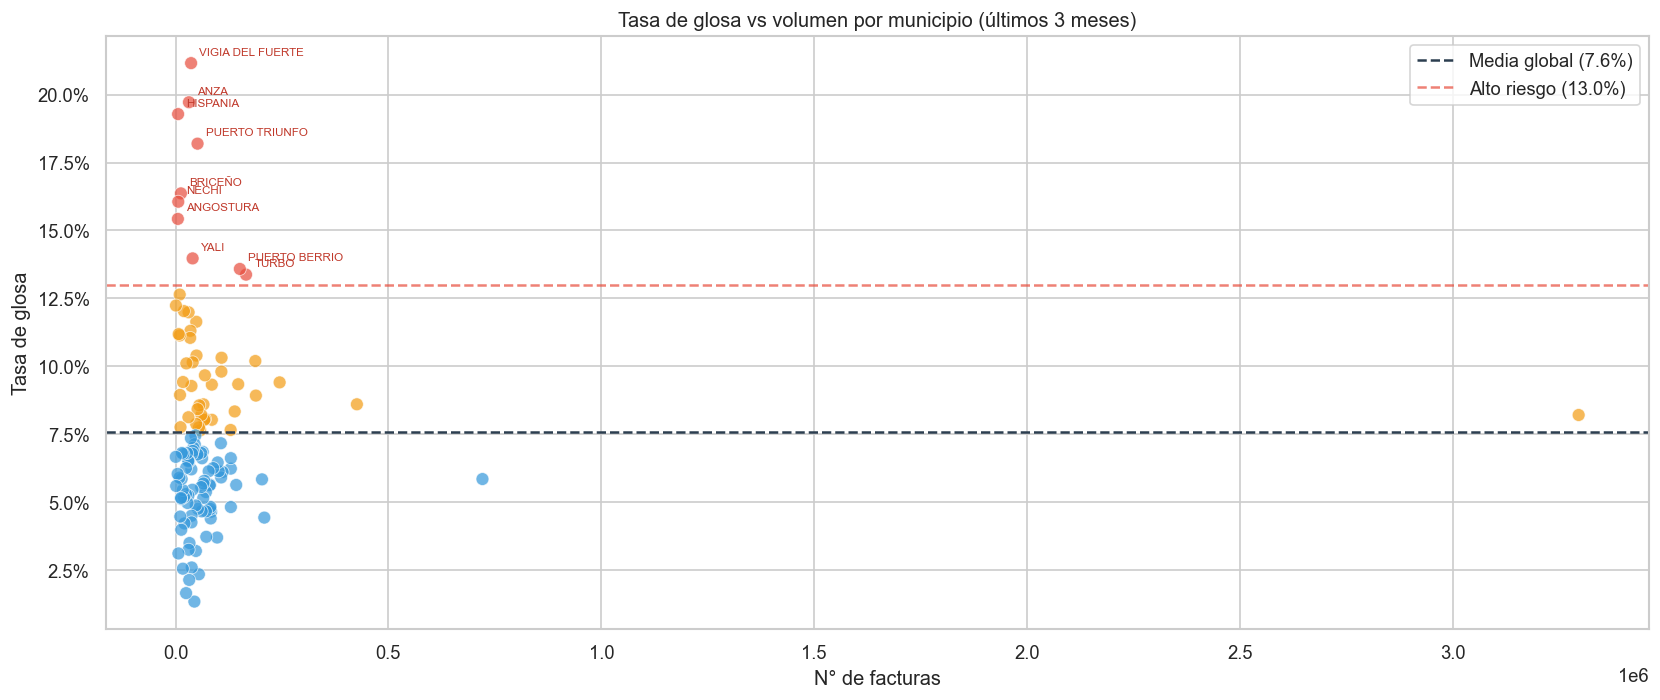

In [15]:
# Gráfica: dispersión n_facturas vs tasa_glosa por municipio
fig, ax = plt.subplots(figsize=(14, 6))

scatter_data = municipios_significativos.copy()
colors_scatter = scatter_data["tasa_glosa"].apply(
    lambda x: "#e74c3c" if x > umbral_alto else ("#f39c12" if x > tasa_global_glosa else "#3498db")
)

ax.scatter(scatter_data["n_facturas"], scatter_data["tasa_glosa"],
           c=colors_scatter, alpha=0.7, s=60, edgecolors="white", linewidths=0.5)
ax.axhline(tasa_global_glosa, color="#2c3e50", linestyle="--", label=f"Media global ({tasa_global_glosa:.1%})")
ax.axhline(umbral_alto, color="#e74c3c", linestyle="--", alpha=0.7, label=f"Alto riesgo ({umbral_alto:.1%})")

# Etiquetar municipios de alto riesgo
for _, row in municipios_alto_riesgo.iterrows():
    ax.annotate(row["municipio_residencia"],
                xy=(row["n_facturas"], row["tasa_glosa"]),
                xytext=(5, 5), textcoords="offset points", fontsize=7, color="#c0392b")

ax.set_xlabel("N° de facturas")
ax.set_ylabel("Tasa de glosa")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Tasa de glosa vs volumen por municipio (últimos 3 meses)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "00_glosas_por_municipio.png", bbox_inches="tight")
plt.show()

## 7 · Distancia afiliado → IPS asignada (Haversine)

Feature clave: afiliados lejos de su IPS asignada pueden tener patrones de uso distintos (urgencias en red diferente, portabilidad, mayor costo).

In [16]:
def haversine_distance(lat1: float, lng1: float, lat2: float, lng2: float) -> float:
    """Calcula distancia en km entre dos puntos GPS usando fórmula Haversine.

    Args:
        lat1: Latitud punto 1 en grados decimales.
        lng1: Longitud punto 1 en grados decimales.
        lat2: Latitud punto 2 en grados decimales.
        lng2: Longitud punto 2 en grados decimales.

    Returns:
        Distancia en kilómetros.
    """
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lng2 - lng1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# Calcular distancia para registros con coordenadas válidas en ambos extremos
df_dist = df.copy()
df_dist["lat_ips_num"] = pd.to_numeric(df_dist["lat_ips"], errors="coerce")
df_dist["lng_ips_num"] = pd.to_numeric(df_dist["lng_ips"], errors="coerce")

# Usar GPS propio del afiliado si existe, si no usar centroide del municipio
df_dist["lat_origen"] = np.where(df_dist["coords_afiliado_validas"], df_dist["lat_afiliado"], df_dist["lat_municipio_res"])
df_dist["lng_origen"] = np.where(df_dist["coords_afiliado_validas"], df_dist["lng_afiliado"], df_dist["lng_municipio_res"])

mask_dist = (
    df_dist["lat_origen"].notna() & df_dist["lng_origen"].notna() &
    df_dist["lat_ips_num"].notna() & df_dist["lng_ips_num"].notna() &
    df_dist["lat_ips_num"].between(lat_min, lat_max) &
    df_dist["lng_ips_num"].between(lng_min, lng_max)
)

df_dist.loc[mask_dist, "distancia_km"] = df_dist.loc[mask_dist].apply(
    lambda r: haversine_distance(r["lat_origen"], r["lng_origen"], r["lat_ips_num"], r["lng_ips_num"]),
    axis=1,
)

n_con_dist = mask_dist.sum()
print(f"Facturas con distancia calculable: {n_con_dist:,} ({n_con_dist/len(df):.1%})")
print(f"\nEstadísticas de distancia afiliado→IPS (km):")
print(df_dist["distancia_km"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))

Facturas con distancia calculable: 11,465,603 (98.7%)

Estadísticas de distancia afiliado→IPS (km):
count    11465603.0
mean           17.6
std            67.7
min             0.0
10%             0.2
25%             0.5
50%             1.2
75%             1.3
90%            47.9
95%            77.3
99%           278.1
max          1070.7
Name: distancia_km, dtype: float64


Distancia promedio afiliado→IPS por clase de auditoría:
          mean  median     count
Auditada  18.1     1.2  10219167
Glosada   14.8     1.3    858385
Devuelta   9.5     1.3    388051


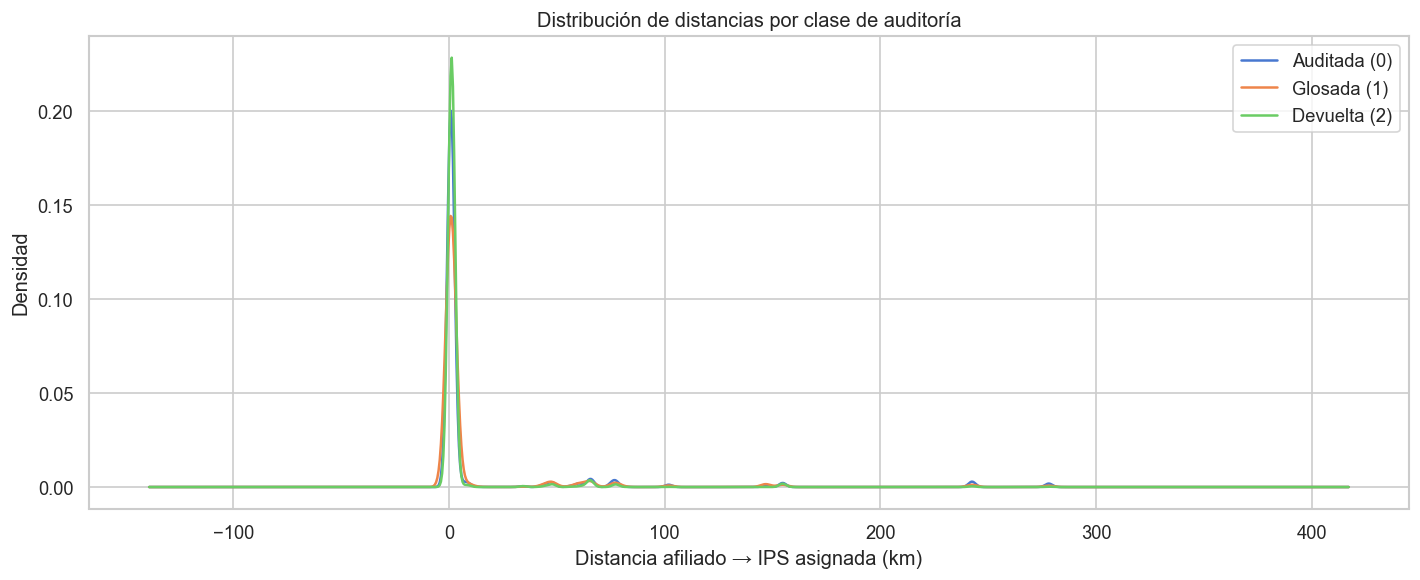

In [17]:
# Distancia media por clase (¿glosadas están más lejos?)
dist_por_clase = df_dist.groupby("target")["distancia_km"].agg(["mean", "median", "count"])
dist_por_clase.index = ["Auditada", "Glosada", "Devuelta"]
print("Distancia promedio afiliado→IPS por clase de auditoría:")
print(dist_por_clase.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
df_dist[df_dist["distancia_km"] < df_dist["distancia_km"].quantile(0.99)].groupby("target")["distancia_km"].plot(
    kind="kde", ax=ax, legend=True
)
ax.set_xlabel("Distancia afiliado → IPS asignada (km)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de distancias por clase de auditoría")
ax.legend(["Auditada (0)", "Glosada (1)", "Devuelta (2)"])
plt.tight_layout()
plt.savefig(FIG_DIR / "00_distancia_por_clase.png", bbox_inches="tight")
plt.show()

## 8 · Concentración diagnóstica por zona (CIE-10 top por municipio)

Identificar focos epidemiológicos: municipios con alta concentración de diagnósticos específicos.

In [18]:
# CIE-10: extraer capítulo (primer carácter) para agrupación
df_dx = df.copy()
df_dx["dx_capitulo"] = df_dx["codigo_dx"].str[:1].str.upper()
df_dx["dx_categoria"] = df_dx["codigo_dx"].str[:3].str.upper()

# Top 10 diagnósticos globales
top_dx = (
    df_dx["dx_categoria"]
    .value_counts()
    .head(15)
    .reset_index()
    .rename(columns={"index": "dx", "dx_categoria": "n"})
)
print("Top 15 diagnósticos globales (últimos 3 meses):")
print(top_dx.to_string(index=False))

Top 15 diagnósticos globales (últimos 3 meses):
Empty DataFrame
Columns: [n, count]
Index: []


In [19]:
# Top 3 diagnósticos por municipio (top 10 municipios por volumen)
top_muns = afiliados_por_municipio.head(10)["municipio_residencia"].tolist()

dx_por_municipio = (
    df_dx[df_dx["municipio_residencia"].isin(top_muns)]
    .groupby(["municipio_residencia", "dx_categoria"])
    .size()
    .reset_index(name="n")
    .sort_values(["municipio_residencia", "n"], ascending=[True, False])
    .groupby("municipio_residencia")
    .head(3)
)

print("Top 3 diagnósticos por municipio (top 10 municipios):")
print(dx_por_municipio.to_string(index=False))

Top 3 diagnósticos por municipio (top 10 municipios):
Empty DataFrame
Columns: [municipio_residencia, dx_categoria, n]
Index: []


In [20]:
# Índice de concentración diagnóstica por municipio (Índice de Herfindahl)
# Alto HHI = pocos diagnósticos dominan (concentración alta)
def herfindahl_index(series: pd.Series) -> float:
    """Calcula índice de Herfindahl-Hirschman (concentración de diagnósticos).

    Args:
        series: Serie de categorías diagnósticas.

    Returns:
        HHI normalizado entre 0 (diversidad máxima) y 1 (concentración máxima).
    """
    counts = series.value_counts(normalize=True)
    return float((counts ** 2).sum())


hhi_municipio = (
    df_dx[df_dx["municipio_residencia"].notna()]
    .groupby("municipio_residencia")["dx_categoria"]
    .apply(herfindahl_index)
    .reset_index()
    .rename(columns={"dx_categoria": "hhi_dx"})
    .merge(afiliados_por_municipio[["municipio_residencia", "n_facturas"]], on="municipio_residencia")
    .sort_values("n_facturas", ascending=False)
)

print("Índice de concentración diagnóstica (HHI) — top 15 municipios por volumen:")
print(
    hhi_municipio.head(15)[["municipio_residencia", "n_facturas", "hhi_dx"]]
    .assign(hhi_dx=lambda x: x["hhi_dx"].round(4))
    .to_string(index=False)
)

Índice de concentración diagnóstica (HHI) — top 15 municipios por volumen:
municipio_residencia  n_facturas  hhi_dx
            MEDELLÍN     3295701     0.0
               BELLO      720917     0.0
              ITAGUI      425963     0.0
            APARTADO      244468     0.0
              CAREPA      208503     0.0
            ENVIGADO      203055     0.0
            RIONEGRO      188700     0.0
            CAUCASIA      187421     0.0
               TURBO      165627     0.0
       PUERTO BERRIO      151074     0.0
              CALDAS      147217     0.0
              SONSON      142512     0.0
           MARINILLA      138967     0.0
    SAN PEDRO DE URA      129980     0.0
          COPACABANA      129881     0.0


## 9 · Brechas de cobertura: municipios sin IPS nivel 1

In [21]:
# Enriquecer municipios con conteos de IPS por nivel
ips_nivel_municipio = (
    df_sedes[df_sedes["estado_sede"] == True]
    .groupby(["municipio", "nivel_atencion"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={1: "n_nivel_1", 2: "n_nivel_2", 3: "n_nivel_3", "municipio": "municipio_residencia"})
)

resumen_brechas = (
    afiliados_por_municipio
    .merge(ips_nivel_municipio, on="municipio_residencia", how="left")
    .fillna({"n_nivel_1": 0, "n_nivel_2": 0, "n_nivel_3": 0})
    .merge(glosas_municipio[["municipio_residencia", "tasa_glosa"]], on="municipio_residencia", how="left")
)

# Municipios con afiliados y sin IPS nivel 1
sin_nivel1 = resumen_brechas[resumen_brechas["n_nivel_1"] == 0].sort_values("n_facturas", ascending=False)
print(f"Municipios con afiliados y sin IPS nivel 1: {len(sin_nivel1)}")
print(f"Facturas en esos municipios: {sin_nivel1['n_facturas'].sum():,}")
print()
print("Top 15 municipios con brecha (más facturas):")
print(
    sin_nivel1.head(15)[["municipio_residencia", "n_facturas", "n_afiliados", "tasa_glosa"]]
    .assign(tasa_glosa=lambda x: x["tasa_glosa"].map("{:.1%}".format))
    .to_string(index=False)
)

Municipios con afiliados y sin IPS nivel 1: 0
Facturas en esos municipios: 0

Top 15 municipios con brecha (más facturas):
Empty DataFrame
Columns: [municipio_residencia, n_facturas, n_afiliados, tasa_glosa]
Index: []


In [22]:
# Guardar resumen de municipios para uso en Fase 1
resumen_path = PROC_DIR / f"{TODAY}_resumen_municipios.parquet"
resumen_brechas.to_parquet(resumen_path, index=False)
logger.info("Resumen de municipios guardado: %s", resumen_path)

INFO | Resumen de municipios guardado: d:\Users\jcardonr\Documents\Savia\Data\processed\20260420_resumen_municipios.parquet


## 10 · Conclusiones y decisiones para Fase 1

In [23]:
# Resumen ejecutivo automático
print("=" * 70)
print("RESUMEN EJECUTIVO — EDA GEOESPACIAL")
print("=" * 70)
print()
print(f"Período analizado:              Últimos 3 meses")
print(f"Total facturas:                 {len(df):,}")
print(f"Municipios únicos:              {df['municipio_residencia'].nunique()}")
print(f"Afiliados únicos:               {df['afiliado_id'].nunique():,}")
print()
print("CALIDAD GEOESPACIAL:")
print(f"  Afiliados con GPS propio:     {n_coords_gps/total:.1%}")
print(f"  Afiliados con centroide mun:  {n_solo_municipio/total:.1%}")
print(f"  Sin georreferenciación:       {n_sin_geo/total:.1%}")
print(f"  IPS con GPS válido:           {n_geo_ips/total_sedes:.1%}")
print()
print("DISTRIBUCIÓN TARGET:")
for t, label in [(0, "Auditada"), (1, "Glosada"), (2, "Devuelta")]:
    n = (df["target"] == t).sum()
    print(f"  Clase {t} ({label}):        {n:>8,}  ({n/len(df):.1%})")
print()
print("HALLAZGOS CLAVE:")
print(f"  Municipios de alto riesgo:    {len(municipios_alto_riesgo)} (tasa glosa > {umbral_alto:.1%})")
print(f"  Municipios sin IPS nivel 1:   {len(sin_nivel1)}")
print(f"  Facturas en zonas de brecha:  {sin_nivel1['n_facturas'].sum():,} ({sin_nivel1['n_facturas'].sum()/len(df):.1%})")
print()
print("DECISIONES PARA FASE 1:")
print("  ✓ Usar centroide de municipio como fallback cuando no hay GPS propio")
print("  ✓ Feature distancia_afiliado_ips_km: calculable con datos disponibles")
print("  ✓ Feature glosa_rate_municipio: alta variabilidad → discriminativo")
print("  ✓ Feature brecha_cobertura_nivel1: municipios sin IPS nivel 1")
print("  ✓ Variable objetivo: 3 clases (Auditada/Glosada/Devuelta) — mantener multiclase")
print("  ✓ División temporal por fecha_radicacion — sin leakage")
print("=" * 70)

RESUMEN EJECUTIVO — EDA GEOESPACIAL

Período analizado:              Últimos 3 meses
Total facturas:                 11,617,161
Municipios únicos:              126
Afiliados únicos:               623,984

CALIDAD GEOESPACIAL:
  Afiliados con GPS propio:     2.2%
  Afiliados con centroide mun:  97.8%
  Sin georreferenciación:       0.0%
  IPS con GPS válido:           6.1%

DISTRIBUCIÓN TARGET:
  Clase 0 (Auditada):        10,348,897  (89.1%)
  Clase 1 (Glosada):         878,946  (7.6%)
  Clase 2 (Devuelta):         389,318  (3.4%)

HALLAZGOS CLAVE:
  Municipios de alto riesgo:    10 (tasa glosa > 13.0%)
  Municipios sin IPS nivel 1:   0
  Facturas en zonas de brecha:  0 (0.0%)

DECISIONES PARA FASE 1:
  ✓ Usar centroide de municipio como fallback cuando no hay GPS propio
  ✓ Feature distancia_afiliado_ips_km: calculable con datos disponibles
  ✓ Feature glosa_rate_municipio: alta variabilidad → discriminativo
  ✓ Feature brecha_cobertura_nivel1: municipios sin IPS nivel 1
  ✓ Variable 

In [24]:
# Guardar dataset enriquecido con flags de calidad geo (input para Fase 1)
cols_guardar = [
    "factura_id", "fecha_radicacion", "nit_prestador", "afiliado_id",
    "zona_afiliado", "nivel_sisben", "regimen", "grupo_poblacional", "genero", "edad",
    "lat_afiliado", "lng_afiliado", "coords_afiliado_validas",
    "municipio_residencia", "region_residencia", "lat_municipio_res", "lng_municipio_res", "municipio_con_cobertura",
    "sede_id", "nombre_sede", "nivel_atencion_ips", "clase_prestador", "capitacion",
    "lat_ips", "lng_ips", "municipio_ips", "region_ips",
    "codigo_dx", "target",
]
cols_guardar = [c for c in cols_guardar if c in df_dist.columns]

if "distancia_km" in df_dist.columns:
    cols_guardar.append("distancia_km")

df_fase0 = df_dist[cols_guardar].copy()
fase0_path = PROC_DIR / f"{TODAY}_geo_eda_fase0.parquet"
df_fase0.to_parquet(fase0_path, index=False)
logger.info("Dataset Fase 0 guardado: %s · %d filas · %d cols", fase0_path, len(df_fase0), len(df_fase0.columns))

print(f"\nDataset Fase 0 guardado: {fase0_path}")
print(f"Filas: {len(df_fase0):,} · Columnas: {len(df_fase0.columns)}")

INFO | Dataset Fase 0 guardado: d:\Users\jcardonr\Documents\Savia\Data\processed\20260420_geo_eda_fase0.parquet · 11617161 filas · 30 cols



Dataset Fase 0 guardado: d:\Users\jcardonr\Documents\Savia\Data\processed\20260420_geo_eda_fase0.parquet
Filas: 11,617,161 · Columnas: 30
